# Basic demonstration of the Icechunk store

First we install the virtualizarr-processor code so we can use the helpers module.

In [7]:
%%capture
%pip install -e lambda/virtualizarr-processor

## 0. Imports

In [8]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import icechunk
import matplotlib.pyplot as plt
import xarray as xr
from virtualizarr_processor.helpers import open_or_create_repo

## 1. Setup storage and open the dataset

In [10]:
storage = icechunk.s3_storage(
    bucket="nasa-eodc-public",
    prefix="icechunk/gpmimerg_hh_07",
    region="us-west-2",
    anonymous=True,
)
repo = open_or_create_repo(storage=storage)

session = repo.readonly_session("main")
ds = xr.open_zarr(session.store, consolidated=False, zarr_version=3, chunks={})
ds

/tmp/ipykernel_1150/66002365.py:10: FutureWarning: zarr_version is deprecated, use zarr_format
  ds = xr.open_zarr(session.store, consolidated=False, zarr_version=3, chunks={})
/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 50TB
Dimensions:                         (time: 486480, lon: 3600, lat: 1800)
Coordinates:
  * time                            (time) datetime64[ns] 4MB 1998-01-01 ... ...
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float32 7kB -89.95 -89.85 ... 89.95
Data variables:
    precipitation                   (time, lon, lat) float32 13TB dask.array<chunksize=(1, 145, 1800), meta=np.ndarray>
    randomError                     (time, lon, lat) float32 13TB dask.array<chunksize=(1, 145, 1800), meta=np.ndarray>
    probabilityLiquidPrecipitation  (time, lon, lat) float32 13TB dask.array<chunksize=(1, 291, 1800), meta=np.ndarray>
    precipitationQualityIndex       (time, lon, lat) float32 13TB dask.array<chunksize=(1, 145, 1800), meta=np.ndarray>
Attributes:
    GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegistration=CENTER;\nLatitudeRe...

## 2. Make a plot

To ensure we can read from the store.

<div class="alert alert-block alert-info">
<b>NOTE:</b>
<ul>
<li>You will only be able to read from the store with proper Earthdata Login credentials set, since the data files are in a protected bucket.</li>
<li>We expect the store to be empty for most time steps at time of writing this notebook.</li>
</ul>
</div>

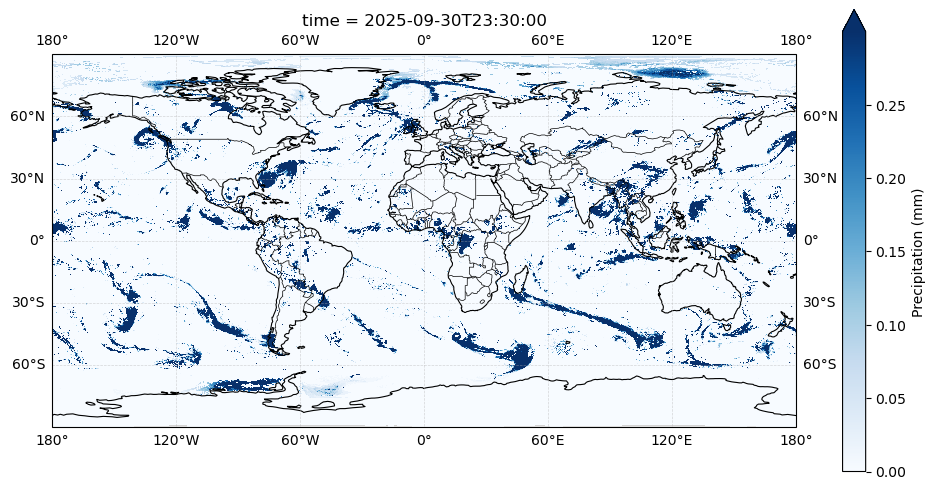

In [11]:
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})

data = ds.precipitation[-1, :, :].transpose("lat", "lon")

vmin = float(data.quantile(0.05))
vmax = float(data.quantile(0.95))

data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Blues",
    vmin=vmin,
    vmax=vmax,
    cbar_kwargs={"label": "Precipitation (mm)"},
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)  # land background
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)  # ocean background
ax.gridlines(draw_labels=True, linewidth=0.5, linestyle="--", alpha=0.5)

plt.show()